In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. Ambil data hasil pre-processing Anda
folder_sumber = r"C:\Users\Balqoz\skripsiku\Hasil ExG"
files = glob.glob(os.path.join(folder_sumber, "Hasil_ExG_*.xlsx"))
df_all = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)

In [2]:
# 2. Feature Engineering: Tambahkan Fitur IR dan Rasio IR terhadap RGB
df_all['IR_to_R'] = df_all['IR_Intensity (%)'] / (df_all['R'] + 1)
df_all['IR_to_G'] = df_all['IR_Intensity (%)'] / (df_all['G'] + 1)
df_all['IR_to_B'] = df_all['IR_Intensity (%)'] / (df_all['B'] + 1)

# Definisikan Fitur X dan Target y
X = df_all[["r", "g", "b", "Excess_Green", "IR_Intensity (%)", "IR_to_R", "IR_to_G", "IR_to_B"]]
y = df_all["Chl_Total"]

In [5]:
loo = LeaveOneOut()

# List penampung nilai Total Klorofil (Target Utama Model)
y_true_total, y_pred_total = [], []

# List penampung komponen pecahan Arnon untuk visualisasi & evaluasi sub-pigmen
y_true_a, y_pred_a = [], []
y_true_b, y_pred_b = [], []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Sederhanakan parameter XGBoost agar cocok dengan data kecil
    xgb_model = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
    xgb_model.fit(X_train, y_train)
    
    # Prediksi nilai total klorofil
    pred_total = xgb_model.predict(X_test)[0]
    actual_total = y_test.values[0]
    
    # Simpan hasil prediksi & aktual Total Klorofil
    y_true_total.append(actual_total)
    y_pred_total.append(pred_total)
    
    # Dekomposisi pecahan Arnon (37% Klorofil a dan 63% Klorofil b)
    y_true_a.append(actual_total * 0.37)
    y_pred_a.append(pred_total * 0.37)
    
    y_true_b.append(actual_total * 0.63)
    y_pred_b.append(pred_total * 0.63)
    
    # Konversi seluruh list menjadi numpy array
y_true_total, y_pred_total = np.array(y_true_total), np.array(y_pred_total)
y_true_a, y_pred_a = np.array(y_true_a), np.array(y_pred_a)
y_true_b, y_pred_b = np.array(y_true_b), np.array(y_pred_b)

In [6]:
# 4. Hitung Metrik Evaluasi Komprehensif untuk Sidang Skripsi
def hitung_metrik(y_true, y_pred, nama_komponen):
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    
    print(f"-------- EVALUASI {nama_komponen.upper()} (XGBOOST + IR) --------")
    print(f"R² Score : {r2:.4f}")
    print(f"MAPE     : {mape:.2f}%")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}\n")

print("=====================================================")
print("       HASIL EVALUASI XGBOOST MULTISENSOR            ")
print("=====================================================")
hitung_metrik(y_true_total, y_pred_total, "Total Klorofil")
hitung_metrik(y_true_a, y_pred_a, "Klorofil a")
hitung_metrik(y_true_b, y_pred_b, "Klorofil b")

       HASIL EVALUASI XGBOOST MULTISENSOR            
-------- EVALUASI TOTAL KLOROFIL (XGBOOST + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.7993
MSE      : 1.6960

-------- EVALUASI KLOROFIL A (XGBOOST + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.2958
MSE      : 0.2322

-------- EVALUASI KLOROFIL B (XGBOOST + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.5036
MSE      : 0.6732



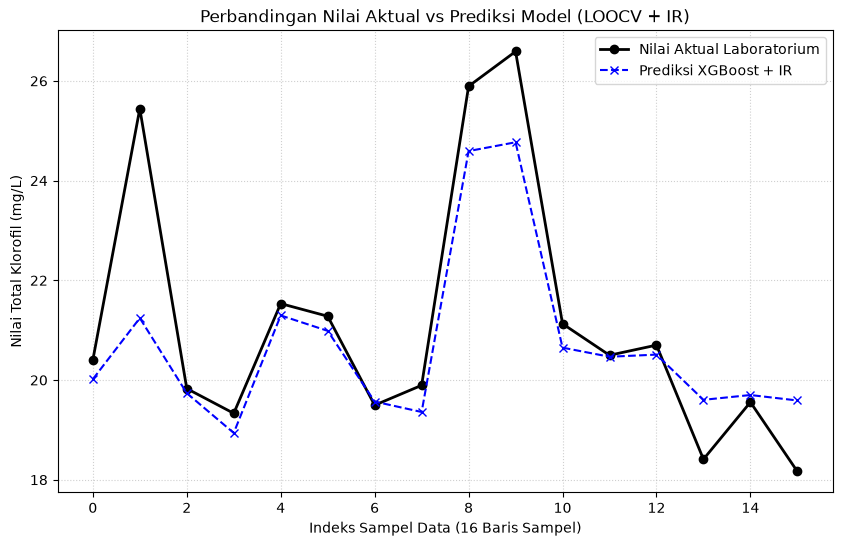

In [7]:
# 5. Visualisasi Hasil
plt.figure(figsize=(10, 6))

# Plot Garis Aktual (Data Acuan Laboratorium)
plt.plot(y_true_total, label='Nilai Aktual Laboratorium', marker='o', linestyle='-', color='black', linewidth=2)

# Plot Hasil Prediksi Model
# Catatan: ganti label di bawah menjadi 'Prediksi XGBoost + IR' jika sedang membuka file XGBoost
plt.plot(y_pred_total, label='Prediksi XGBoost + IR', marker='x', linestyle='--', color='blue', linewidth=1.5)

plt.title('Perbandingan Nilai Aktual vs Prediksi Model (LOOCV + IR)')
plt.xlabel('Indeks Sampel Data (16 Baris Sampel)')
plt.ylabel('Nilai Total Klorofil (mg/L)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [8]:
import joblib

# Latih ulang model pada SELURUH data (16 baris) dengan fitur lengkap agar pengetahuannya maksimal
xgb_model_final = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
xgb_model_final.fit(X, y)

# Simpan model final XGBoost ke dalam file .pkl
joblib.dump(xgb_model_final, 'model_xgb.pkl')
print("Model XGBoost berhasil disimpan dengan nama 'model_xgb.pkl'!")

Model XGBoost berhasil disimpan dengan nama 'model_xgb.pkl'!
